**Dataset:** the [UCI](https://archive.ics.uci.edu/dataset/292/wholesale+customers) dataset, with the annual spending (in monetary units) of 440 clients across six product categories, plus their sales channel (Horeca or Retail).

**Objective:** segment the clients by their purchasing behaviour, and suggest actions for the business and marketing teams

**Approach:** K-menas is a unsupervised method, so there is no outcome to be predicted. The algorithm finds patterns in the data on its own,

I log-transform and scale the spending, choose the number of clusters with the elbow method and silhouette score, and use PCA to visualize the results. I then run a second clustering inside the Retail channel to look for sub-profiles.

**Result:** We came up with 4 segments, Horeca + three retail profiles. The segments overlap (they have weak separation, silhouette about 0.25), but they are stable across random seeds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


### 1. Obtain the data


In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets

# metadata
print(wholesale_customers.metadata)

# variable information
print(wholesale_customers.variables)


{'uci_id': 292, 'name': 'Wholesale customers', 'repository_url': 'https://archive.ics.uci.edu/dataset/292/wholesale+customers', 'data_url': 'https://archive.ics.uci.edu/static/public/292/data.csv', 'abstract': 'The data set refers to clients of a wholesale distributor. It includes the annual spending in monetary units (m.u.) on diverse product categories', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 440, 'num_features': 7, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Region'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Mon Feb 05 2024', 'dataset_doi': '10.24432/C5030X', 'creators': ['Margarida Cardoso'], 'intro_paper': None, 'additional_info': {'summary': None, 'purpose': None, 'funded_by': None, 'instances_represent': None, 'recommended_data_splits': None, 'sensitive_data': None, 'preprocessing_description':

In [4]:
X.head()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


Drop columns

In [5]:
X_num = X.drop(columns=['Channel'])

In [6]:
y['Region']

,Region
0,3
1,3
2,3
3,3
4,3
...,...
435,3
436,3
437,3
438,3


### 2. Standardization



First let's apply the log 10 in the values, to reduce skewness of the data and skip Channel column because it should not be considered as a variable to the model.

Region (the target y) is unused, since you are doing unsupervised clustering.

In [7]:
X_log = X_num.apply(lambda x: np.log10(1+x))

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

### 3. Run the Elbow method to calculate the ideal number of clusters

Calculate inertia for different values of k

In [9]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

In [10]:
inertia

[1844.0640687542132,
 1553.4213271044882,
 1386.8627413918157,
 1266.1493615004895,
 1174.7586330617391,
 1086.358699956313,
 1028.4862172508097,
 973.1414829897634,
 931.9984643726273]

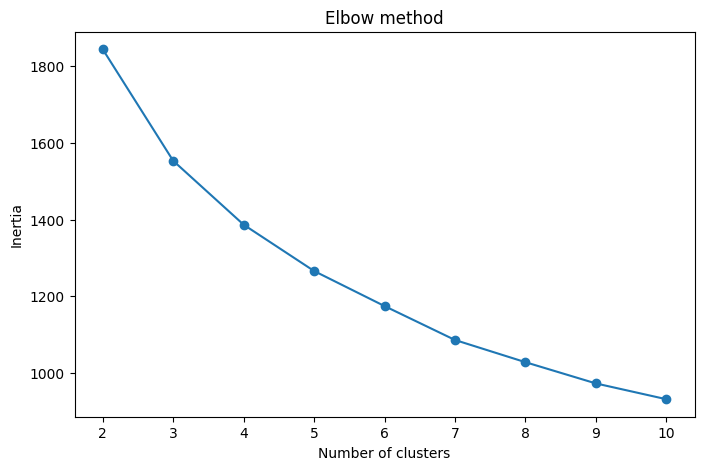

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2, 11),
    inertia,
    marker = 'o'
)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow method')
plt.show()


Looking at the graph the elbow is ambiguous, with no clear bend. We can't make the final decision from the elbow alone. We need to calculate the Silhouette Score.

### Silhouette Score

In [12]:
silhouette_scores = []

for k in range(2, 11):
  kmeans = KMeans(
      n_clusters = k,
      random_state = 42,
      n_init = 10
  )
  labels = kmeans.fit_predict(X_scaled)

  score = silhouette_score(X_scaled, labels)
  silhouette_scores.append(score)

In [13]:
silhouette_scores

[np.float64(0.2903284869973543),
 np.float64(0.25941565559741453),
 np.float64(0.1884954525130424),
 np.float64(0.19158508431915208),
 np.float64(0.200886993074694),
 np.float64(0.19577973280303204),
 np.float64(0.18517472607336674),
 np.float64(0.19650108536770935),
 np.float64(0.1905229602145307)]

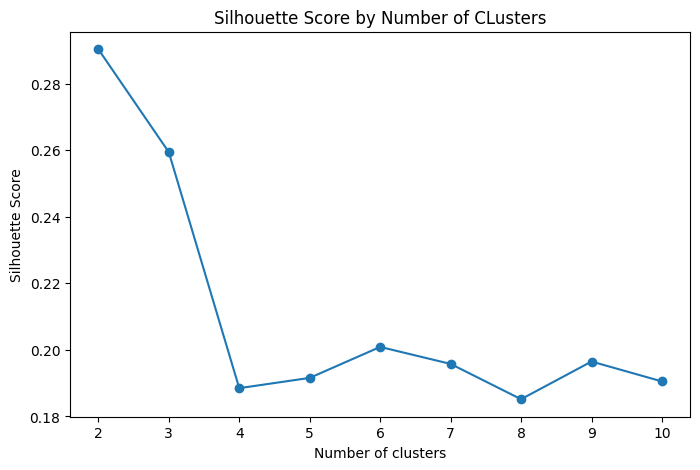

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker = 'o'
)

plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of CLusters')
plt.show()

The dataset has a Channel column with exactly 2 values (Horeca and Retail), so choosing k = 2 would only rebuild Channel and not bring any real value.
I chose k = 3 to get a finer split of the retail customers.

### 4. Build the K-Means model with 3 clusters

---



In [15]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [16]:
clusters = kmeans.labels_
clusters[:10]


array([1, 1, 1, 2, 1, 1, 1, 1, 0, 1], dtype=int32)

In [17]:
X_clustered = X.copy()

X_clustered['cluster'] = clusters

X_clustered.head()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,2,12669,9656,7561,214,2674,1338,1
1,2,7057,9810,9568,1762,3293,1776,1
2,2,6353,8808,7684,2405,3516,7844,1
3,1,13265,1196,4221,6404,507,1788,2
4,2,22615,5410,7198,3915,1777,5185,1


In [18]:
X_clustered['cluster'].value_counts().sort_index()

,count
cluster,
0,80
1,147
2,213


### 5. Visualize the clusters

For the UCI Wholesale dataset, we have 6 dimensions and we can't plot them all. So the solution is to compress the data into 2 components by using the Principal Component Analysis. Mind that the PCA is for display only and It could be a separate analysis itself.

In [19]:
from sklearn.decomposition import PCA

# 1. Project the scaled data onto 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 2. How much of the total variation do these 2 axes keep?
print("Explained variance per component:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance per component: [0.44077752 0.27194917]
Total explained variance: 0.7127266893428759


The two components together sum a variance of 71.3%, which is a good result.
It means that the 2 components keep a 71.3% of the data variance from the 6  original variables. In other words, the 2D plot keeps 71% of the information in the 6 features. The other 29% is squeezed out, so some of the points that look close in the plot may be further apart in the full 6D space.

PC1 is the dominant axis.

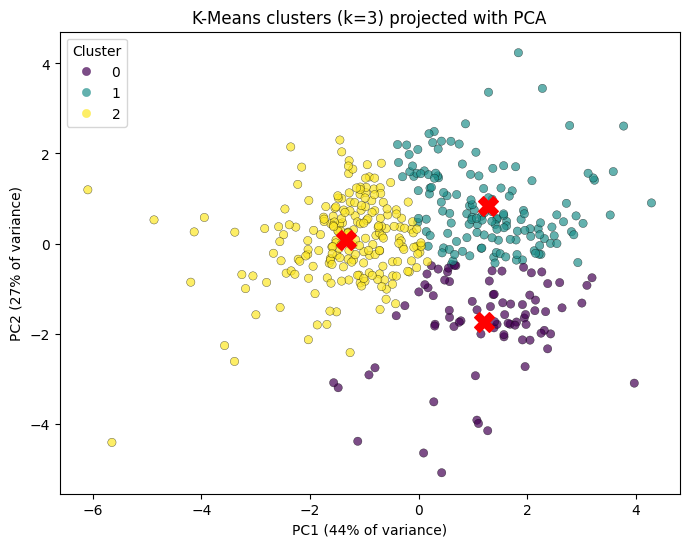

In [20]:
# 3. Scatter plot coloured by cluster
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=X_clustered['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# 4. Project the cluster centroids into the same 2D space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)')
plt.title('K-Means clusters (k=3) projected with PCA')
plt.legend(*scatter.legend_elements(), title='Cluster', loc='best')
plt.show()

There are 3 distinguishable regions that touch and overlap.
The silhouette score for k = 3 was 0.26. This score indicates that clusters are adjacent and that they overlap, not isolated islands. It reflects what we see in the plot.

In [21]:
# PCA loadings -> shows how much each riginal feature contributes to each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=X_log.columns
).round(2)
loadings

,PC1,PC2
Fresh,-0.11,0.59
Milk,0.54,0.13
Grocery,0.57,-0.01
Frozen,-0.14,0.59
Detergents_Paper,0.55,-0.07
Delicassen,0.21,0.53



*   PC1 is driven by Grocery, Detergents_Paper and Milk, so it is the "packaged goods" axis.

*   PC2 is driven by Fresh, Frozen and Delicassen, so it is the "fresh, frozen and deli" axis.




Same plot by channel instead of cluster

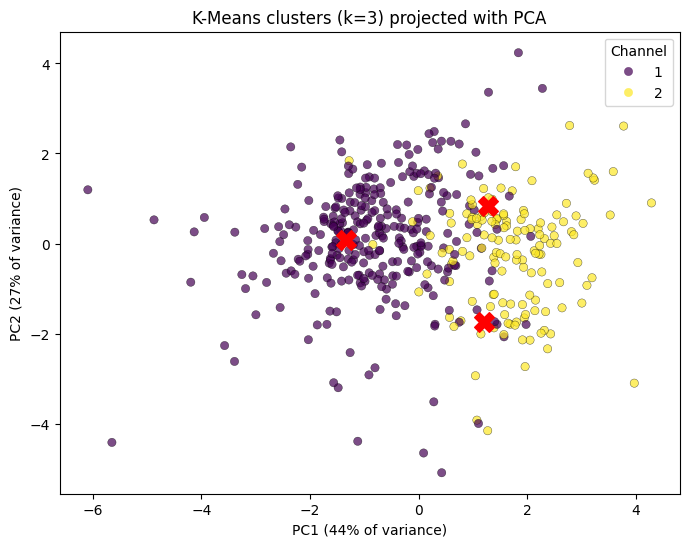

In [22]:
# 3. Scatter plot coloured by cluster
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=X_clustered['Channel'],
    cmap='viridis',
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# 4. Project the cluster centroids into the same 2D space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)')
plt.title('K-Means clusters (k=3) projected with PCA')
plt.legend(*scatter.legend_elements(), title='Channel', loc='best')
plt.show()

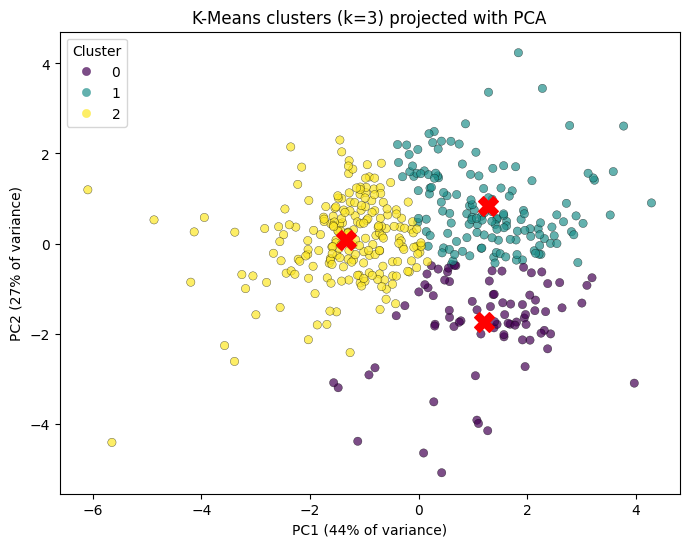

In [23]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=X_clustered['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# 4. Project the cluster centroids into the same 2D space
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} of variance)')
plt.title('K-Means clusters (k=3) projected with PCA')
plt.legend(*scatter.legend_elements(), title='Cluster', loc='best')
plt.show()

In [24]:
spend_cols = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']

# 1. Real-unit profile of each cluster
X_clustered.groupby('cluster')[spend_cols].mean().round(0)

# 2. Does the cluster line up with Channel (1 = Horeca, 2 = Retail)?
pd.crosstab(X_clustered['cluster'], X_clustered['Channel'], normalize='index').round(2)

Channel,1,2
cluster,,
0,0.40,0.60
1,0.38,0.62
2,0.99,0.01


In [25]:
# Profile the clusters
X_clustered.groupby('cluster').mean()

,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,,
0,1.600000,2898.575000,7135.937500,12569.712500,606.550000,5554.387500,782.862500
1,1.619048,17042.836735,10559.666667,13333.598639,4133.095238,4987.020408,2846.591837
2,1.014085,11938.723005,2005.685446,2502.093897,3265.544601,424.478873,891.384977


In [26]:
X_clustered.groupby('Channel').mean()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
Channel,,,,,,,
1,13475.560403,3451.724832,3962.137584,3748.251678,790.560403,1415.956376,1.597315
2,8904.323944,10716.500000,16322.852113,1652.612676,7269.507042,1753.436620,0.683099


In [27]:
X_clustered.mean()

,0
Channel,1.322727
Fresh,12000.297727
Milk,5796.265909
Grocery,7951.277273
Frozen,3071.931818
Detergents_Paper,2881.493182
Delicassen,1524.870455
cluster,1.302273


Channel 1 = Horeca (buys more Fresh, and less of the rest)

Channel 2 = Retail

In [28]:
pd.crosstab(X_clustered['cluster'], X_clustered['Channel'])

Channel,1,2
cluster,,
0,32,48
1,56,91
2,210,3


Horeca fell majorly in Cluster 2.

Retail is kind of spread, but majorly fell within clusters 0 and 1. But we can say that within Retail there are different patterns of consumption.

In [29]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

print("Silhouette:", silhouette_score(X_scaled, clusters))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, clusters))
print("Calinski-Harabasz:", calinski_harabasz_score(X_scaled, clusters))
print("ARI vs Channel:", adjusted_rand_score(X['Channel'], clusters))

Silhouette: 0.25941565559741453
Davies-Bouldin: 1.340563134280772
Calinski-Harabasz: 152.83518765009214
ARI vs Channel: 0.3504030230464735


Metrics for the full-data model (k = 3):

**Silhouette 0.26**: weak structure, clusters overlap.
Davies-Bouldin 1.34: clusters are not very distinct (lower is better; below 1 would be good).
**Calinski-Harabasz 152.8**: only meaningful when compared against another k, so on its own it says little.
**ARI vs Channel 0.35**: modest agreement. The clusters recover part of the Horeca/Retail split, mainly through cluster 2, but clusters 0 and 1 mix both channels.

### 6. Two-stage Clustering filtered by Retail only

In [30]:
retail = X[X['Channel']==2].drop(columns = ['Channel'])

retail_log = np.log1p(retail)
retail_scaled = StandardScaler().fit_transform(retail_log)

inertia_r, sil_r = [], []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(retail_scaled)
    inertia_r.append(km.inertia_)
    sil_r.append(silhouette_score(retail_scaled, labels))

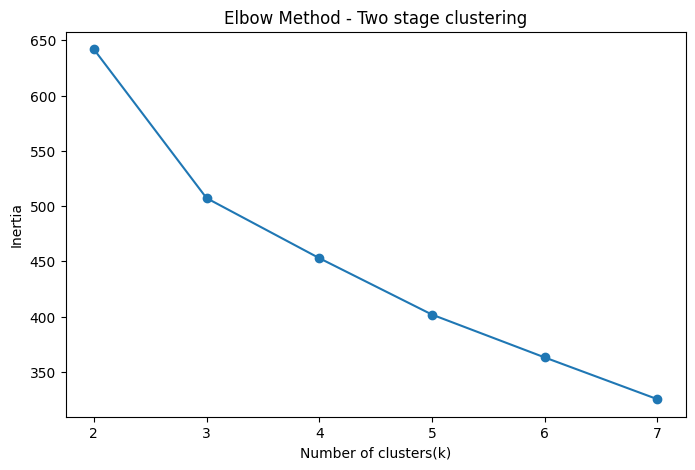

In [31]:
# Elbow curve

plt.figure(figsize = (8, 5))

plt.plot(
    range(2, 8),
    inertia_r,
    marker='o'
)

plt.xlabel('Number of clusters(k)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Two stage clustering')
plt.show()

Looking at the graph we can infer that the ideal # of clusters is 3. After 3, the fall is not so high anymore. But don't make the final decision from the elbow alone. We need to calculate the Silhouette Score.

Silhouette score: For each point, how close it is to its own cluster versus the nearest other cluster. Higher is better

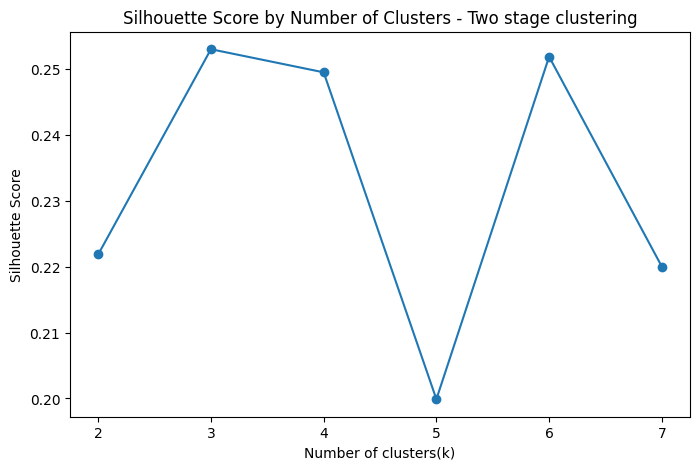

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 8),
    sil_r,
    marker='o'
)

plt.xlabel('Number of clusters(k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters - Two stage clustering')

plt.show()

In [33]:
sil_r

[np.float64(0.22188514012957933),
 np.float64(0.25306173625036543),
 np.float64(0.2495511170625421),
 np.float64(0.19988388694796774),
 np.float64(0.2519252763574486),
 np.float64(0.22002699053056943)]

k=3: 0.253, k=4: 0.250, k=6: 0.252

k = 3 is marginally best, and k = 4 and 6 are almost tied, so I choose 3 for interpretability



### 6.1. Build the K-Means Retail model with 3 clusters - Part 2 (Retail)

---

In [34]:
kmeans_retail = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
kmeans_retail.fit(retail_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [35]:
#get the clusters assignments -> the cluster assigned to each row

clusters_r = kmeans_retail.labels_

clusters_r[:10]

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1], dtype=int32)

In [36]:
retail_clustered = retail.copy()
retail_clustered['cluster'] = clusters_r
retail_clustered.head()


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,cluster
0,12669,9656,7561,214,2674,1338,1
1,7057,9810,9568,1762,3293,1776,1
2,6353,8808,7684,2405,3516,7844,1
4,22615,5410,7198,3915,1777,5185,1
5,9413,8259,5126,666,1795,1451,1


In [37]:
# how many records per cluster?
retail_clustered['cluster'].value_counts().sort_index()

,count
cluster,
0,40
1,59
2,43


In [38]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("Silhouette:", silhouette_score(retail_scaled, clusters_r))
print("Davies-Bouldin:", davies_bouldin_score(retail_scaled, clusters_r))
print("Calinski-Harabasz:", calinski_harabasz_score(retail_scaled, clusters_r))

Silhouette: 0.25306173625036543
Davies-Bouldin: 1.4022532874137525
Calinski-Harabasz: 47.2483957725801


Retail-only metrics (k = 3): silhouette 0.25 and Davies-Bouldin 1.40 show weak separation, similar to the full-data model (0.26 and 1.34). Calinski-Harabasz (47.2) can't be compared with the full-data value because the datasets have different sizes. The three profiles are therefore useful descriptions of regions in a continuum, not sharply separated groups.

### 6.2. Visualize the clusters - Part 2 (Retail)


In [39]:
from sklearn.decomposition import PCA

# 1. Project the scaled data onto 2 principal components
pca_retail = PCA(n_components=2, random_state=42)
retail_pca = pca_retail.fit_transform(retail_scaled)

# 2. How much of the total variation do these 2 axes keep?
print("Explained variance per component:", pca_retail.explained_variance_ratio_)
print("Total explained variance:", pca_retail.explained_variance_ratio_.sum())

Explained variance per component: [0.41125073 0.26619885]
Total explained variance: 0.6774495827967377


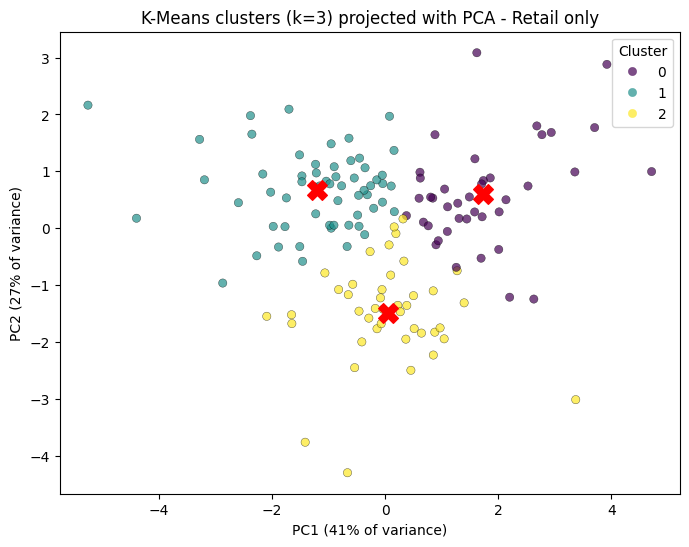

In [40]:
# 3. Scatter plot coloured by cluster
plt.figure(figsize=(8, 6))

scatter_retail = plt.scatter(
    retail_pca[:, 0],
    retail_pca[:, 1],
    c=retail_clustered['cluster'],
    cmap='viridis',
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# 4. Project the cluster centroids into the same 2D space
centroids_pca_retail = pca_retail.transform(kmeans_retail.cluster_centers_)
plt.scatter(
    centroids_pca_retail[:, 0],
    centroids_pca_retail[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel(f'PC1 ({pca_retail.explained_variance_ratio_[0]:.0%} of variance)')
plt.ylabel(f'PC2 ({pca_retail.explained_variance_ratio_[1]:.0%} of variance)')
plt.title('K-Means clusters (k=3) projected with PCA - Retail only')
plt.legend(*scatter_retail.legend_elements(), title='Cluster', loc='best')
plt.show()

In [41]:
loadings_retail = pd.DataFrame(
    pca_retail.components_.T,
    columns=['PC1', 'PC2'],
    index=retail_log.columns
).round(2)
loadings_retail

,PC1,PC2
Fresh,-0.10,0.58
Milk,0.53,0.21
Grocery,0.60,-0.07
Frozen,-0.03,0.59
Detergents_Paper,0.58,-0.12
Delicassen,0.14,0.50


*   PC1 is driven by Milk, Grocery, and Detergents_Paper
*   PC2 is driven by Fresh, Frozen and Delicassen

In [42]:
# Profile the clusters
retail_clustered.groupby('cluster').mean()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,9726.100000,19936.125000,28291.300000,2164.925000,12997.725000,2478.500000
1,12970.711864,6253.169492,8999.915254,2161.864407,3543.762712,1805.203390
2,2560.418605,8264.209302,15237.162791,477.302326,7053.000000,1007.930233


In [43]:
profile = retail_clustered.groupby('cluster')[spend_cols].mean()
ratio = (profile / retail[spend_cols].mean()).round(2)
ratio

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,1.09,1.86,1.73,1.31,1.79,1.41
1,1.46,0.58,0.55,1.31,0.49,1.03
2,0.29,0.77,0.93,0.29,0.97,0.57


In [44]:
retail_clustered.mean().drop('cluster')

,0
Fresh,8904.323944
Milk,10716.500000
Grocery,16322.852113
Frozen,1652.612676
Detergents_Paper,7269.507042
Delicassen,1753.436620


###Stability check:
I refit the Retail model (k = 3) with five different random seeds and compared each result to the baseline using the Adjusted Rand Index. All scores were 0.978 or higher, so the clusters are stable. The small differences most likely come from one or two clients on cluster boundaries, which is consistent with the weak silhouette score.

In [45]:
from sklearn.metrics import adjusted_rand_score

baseline = clusters_r

for seed in [0, 1, 7, 123, 2024]:
    km = KMeans(n_clusters=3, random_state=seed, n_init=10)
    labels_seed = km.fit_predict(retail_scaled)

    ari = adjusted_rand_score(baseline, labels_seed)
    print(f"random_state={seed}: ARI vs baseline = {ari:.3f}")

random_state=0: ARI vs baseline = 1.000
random_state=1: ARI vs baseline = 0.978
random_state=7: ARI vs baseline = 0.978
random_state=123: ARI vs baseline = 1.000
random_state=2024: ARI vs baseline = 0.978


The clusters are stable

### 7. Final conclusion

The final recommended segmentation is Horeca + three Retail profiles, totaling 4 customer profiles

1. Horeca | n = 298
2. Retail A | n = 40: big-basket packaged buyers (milk, grocery, detergents about 1.7 to 1.9 times the Retail average)
3. Retail B | n = 59: fresh-leaning retailers (fresh and frozen above average, packaged goods low)
4. Retail C | n = 43: dry-goods-only retailers (almost no fresh or frozen)

We first ran a cluster model with all the clients, and we got one clear Horeca cluster and two mixed clusters. That result led us to think that we had room to explore deeper the retail channel. When we did that, we found three retail profiles.

The result comes with some caveats.
The Silhouette scores were weak, and the sample size for the retail subgroup is small, 142 records only.
In the full-data model, the Horeca cluster is 99% pure but holds only 210 of the 298 Horeca clients. In the final segmentation, Horeca comes from the Channel label, not from the model.
The stability result was 0.978 or higher, the clusters are stable.


We suggest that:

*  Horeca gets a fresh promotion
*  Retail A gets volume pricing on packaged goods, where they already buy heavily.
*  Retail B gets a fresh and frozen promotion, the categories they already buy
*  Retail C gets coupons with discounts to encourage more purchases


